In [32]:
import pandas as pd
from glob import glob
pd.set_option('display.float_format', lambda x: f'{x:.2f}')
import matplotlib.pyplot as plt


In [33]:
corpora = pd.read_parquet("../../corpora/GeneratedCorpus/corpora_v3.parquet")

corpora = corpora.reset_index(names='text_id')

display(corpora.head())
print(corpora.shape)

,text_id,scenario,language,task,task_type,text
0,0,GRAMMAR SWAP,INGLÊS,CAPACITAR,ED,"Fondant / Pasta de goma Ei todos, boa noite! E..."
1,1,GRAMMAR SWAP,INGLÊS,CAPACITAR,ED,"Querido Sr. Ministro, Como eu escrevo isso, eu..."
2,2,GRAMMAR SWAP,INGLÊS,CAPACITAR,ED,Tens notado como diferentes teus pais têm sido...
3,3,GRAMMAR SWAP,INGLÊS,CAPACITAR,ED,Uma Carta Aberta Na página 2 da Folha de S.Pau...
4,4,GRAMMAR SWAP,INGLÊS,CAPACITAR,ED,Carta Aberta Nazismo revelou a face mais escur...


(1680, 6)


In [34]:
results = pd.DataFrame()

for res in glob("./results/*"):
    temp = pd.read_csv(res)
    temp["model"] = res.split("/")[-1].replace(".csv", "")
    results = pd.concat([results, temp])

display(results.head())

print(results.shape)

,text_id,num_words,num_bytes,num_tokens,tokens_per_word,average_nll,total_nll,ppl,bpb,model
0,0,153,999,241,1.58,2.80,672.95,16.51,0.97,Gemma4-12B
1,1,173,1103,245,1.42,2.79,681.10,16.30,0.89,Gemma4-12B
2,2,156,945,215,1.38,3.18,681.45,24.15,1.04,Gemma4-12B
3,3,169,1018,238,1.41,3.17,750.62,23.74,1.06,Gemma4-12B
4,4,173,1070,230,1.33,3.27,749.17,26.35,1.01,Gemma4-12B


(15120, 10)


In [35]:
df = pd.merge(results, corpora)

In [36]:
df["scenario"].unique()

<ArrowStringArray>
[   'GRAMMAR SWAP',    'LEXICAL SWAP',     'TRANSLATION',       'PB NATIVO',
     'PB PERMUTED',    'PB CORRUPTED', 'GRAMMAR SWAP v2', 'GRAMMAR SWAP v3']
Length: 8, dtype: str

In [37]:
df = df[~df["scenario"].isin(["GRAMMAR SWAP", "GRAMMAR SWAP v2"])]


# Analise das perplexidades e BPB dos modelos

In [52]:
ppl = df.groupby(["model"])["ppl"].describe().sort_values(by='mean')
ppl

,count,mean,std,min,25%,50%,75%,max
model,,,,,,,,
Sabia 7B,1472.00,26.12,31.45,2.24,10.81,18.65,32.33,551.10
Qwen3.5-9B,1472.00,32.28,51.72,3.88,10.80,17.39,30.71,550.20
Gemma4-12B,1472.00,32.28,46.91,3.50,12.75,18.91,31.92,556.14
Qwen3.5-9B-it,1472.00,36.45,59.66,4.11,11.51,19.12,34.93,656.73
Cabrita,1472.00,48.38,58.04,4.39,16.78,31.31,58.53,593.76
Tucano-2b4,1472.00,58.89,96.53,2.56,14.81,29.02,62.37,974.30
Tucano-2b4-it,1472.00,61.73,103.21,2.67,15.26,30.18,64.92,1077.84
Manaca,1472.00,105.15,163.69,3.57,24.12,45.18,109.25,1669.60
Gemma4-12B-it,1472.00,740685076.01,4502808364.29,122.86,26960.44,177942.11,1967269.32,89888693000.34


In [53]:
bpb = df.groupby(["model"])["bpb"].describe().sort_values(by='mean')
bpb

,count,mean,std,min,25%,50%,75%,max
model,,,,,,,,
Qwen3.5-9B,1472.00,1.24,0.41,0.42,0.94,1.19,1.48,2.80
Gemma4-12B,1472.00,1.25,0.41,0.35,0.94,1.17,1.52,2.75
Qwen3.5-9B-it,1472.00,1.28,0.42,0.44,0.97,1.23,1.54,2.84
Sabia 7B,1472.00,1.53,0.59,0.31,1.06,1.45,1.98,4.44
Tucano-2b4,1472.00,1.70,0.70,0.23,1.13,1.46,2.31,3.47
Tucano-2b4-it,1472.00,1.72,0.71,0.24,1.15,1.47,2.33,3.52
Cabrita,1472.00,1.72,0.63,0.48,1.21,1.56,2.25,3.34
Manaca,1472.00,1.84,0.73,0.30,1.28,1.59,2.42,3.61
Gemma4-12B-it,1472.00,5.19,1.65,1.51,3.98,4.95,6.27,13.18


- Removendo modelos it

In [55]:
df = df[~df["model"].isin(["Qwen3.5-9B-it", "Tucano-2b4-it", "Gemma4-12B-it"])]

In [62]:
df["language"].unique()

<ArrowStringArray>
[   'INGLÊS',  'ESPANHOL',     'RUSSO',    'GALEGO',     'ÁRABE',  'MANDARIM',
   'FRANCÊS', 'PB NATIVO']
Length: 8, dtype: str

# Resultados dos textos em português ou inglês

In [70]:
df[df["language"].isin(['PB NATIVO', 'INGLÊS'])].groupby(["scenario"])["ppl"].describe().sort_values(by='mean')

,count,mean,std,min,25%,50%,75%,max
scenario,,,,,,,,
TRANSLATION,492.00,15.64,8.32,4.10,9.52,13.77,19.64,72.81
PB NATIVO,492.00,21.11,15.50,2.24,10.75,16.87,26.78,119.37
GRAMMAR SWAP v3,492.00,29.26,19.26,3.16,14.25,24.53,37.97,123.68
LEXICAL SWAP,492.00,35.11,27.71,6.82,18.58,27.81,42.88,266.05
PB CORRUPTED,492.00,70.95,65.00,6.58,29.58,51.43,87.74,549.36
PB PERMUTED,492.00,263.13,249.51,6.86,82.92,182.84,346.15,1669.60


# Gráfico de perplexidade e BPB

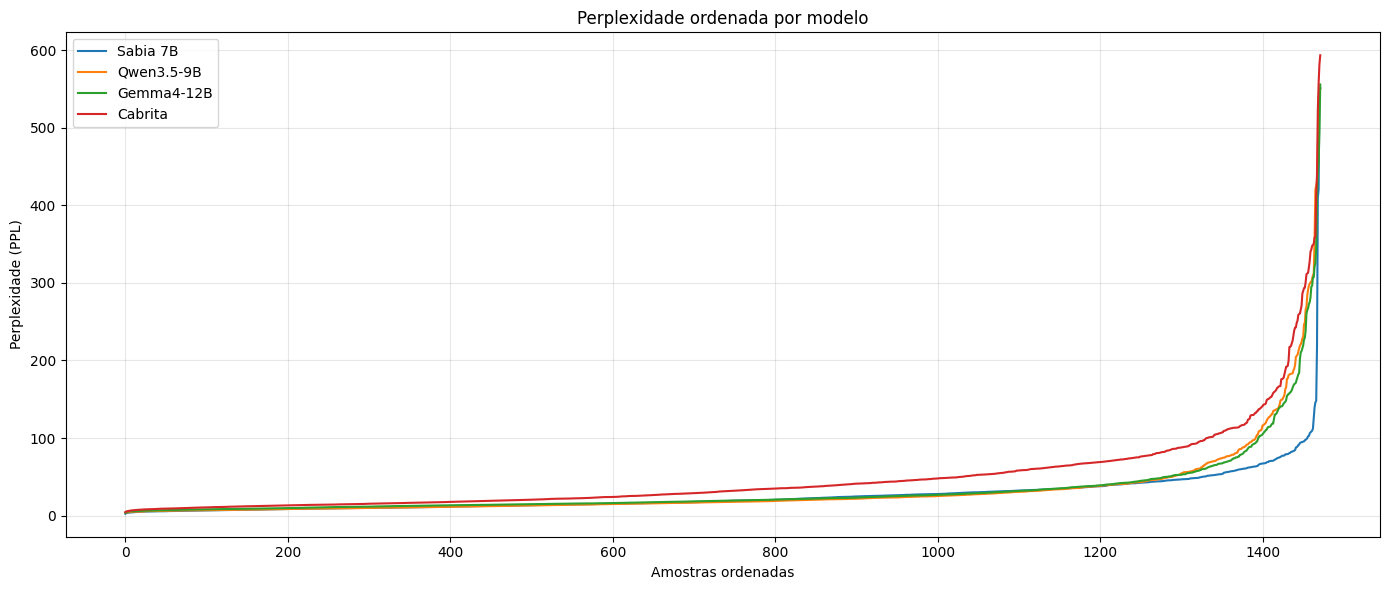

In [51]:
plt.figure(figsize=(14, 6))

for model in ["Sabia 7B", "Qwen3.5-9B", "Gemma4-12B", "Cabrita"]:
    y = sorted(df[df["model"] == model]["ppl"].to_list())
    x = range(len(y))

    plt.plot(x, y, label=model)

plt.xlabel("Amostras ordenadas")
plt.ylabel("Perplexidade (PPL)")
plt.title("Perplexidade ordenada por modelo")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

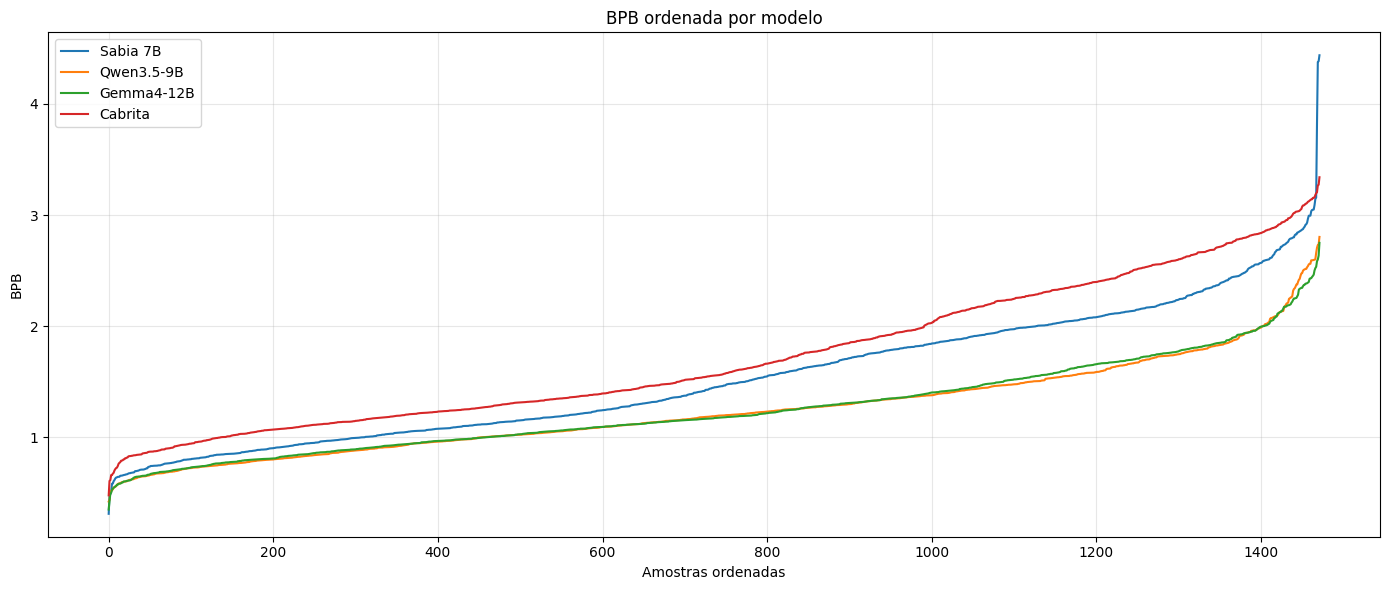

In [61]:
plt.figure(figsize=(14, 6))

for model in ["Sabia 7B", "Qwen3.5-9B", "Gemma4-12B", "Cabrita"]:
    y = sorted(df[df["model"] == model]["bpb"].to_list())
    x = range(len(y))

    plt.plot(x, y, label=model)

plt.xlabel("Amostras ordenadas")
plt.ylabel("BPB")
plt.title("BPB ordenada por modelo")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()